# Backblaze Hard Drive Failure Prediction Pipeline

End-to-end pipeline covering:
1. **Data Cleaning** — column filtering and missing value imputation
2. **Temporal Aggregation** — rolling window features per disk
3. **RFOD Anomaly Scores** — in-notebook RFOD training and multi-threshold scoring
4. **XGBoost Classification** — RUL class prediction with hyperparameter tuning
5. **Cost Matrix Evaluation** — asymmetric cost-based RUL assessment

In [141]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
    log_loss, roc_auc_score,
)
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

PROJECT_DIR = Path(".").resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from backblaze_feature_engineering import (
    clean_train_val_datasets,
    build_feature_dataset,
    temporal_aggregation,
    generate_validation_labels,
    patch_missing_values,
)
from train_xgboost_backblaze import (
    COST_MATRIX,
    total_cost,
    align_feature_frames,
    build_model_pipeline,
    tune_pipeline,
    evaluate_predictions,
    load_aggregated_train_val,
)

RANDOM_STATE = 42
print("Imports OK")

Imports OK


In [142]:
DATA_DIR      = PROJECT_DIR / "Datasets" / "Backblaze" / "backblaze_data"
CLEAN_DIR     = PROJECT_DIR / "Datasets" / "Backblaze" / "clean"

TRAIN_RAW     = DATA_DIR / "train_set.csv"
VAL_RAW       = DATA_DIR / "val_set.csv"
VAL_IDS       = DATA_DIR / "val_serial_number_id.csv"
VAL_LABELS    = DATA_DIR / "val_label.csv"

TRAIN_AGG_OUT = CLEAN_DIR / "backblaze_clean_train_feature_agg.csv"
VAL_AGG_OUT   = CLEAN_DIR / "backblaze_clean_val_feature_agg.csv"

WINDOW_SIZE   = 30
SAMPLE_FRAC   = 0.5   # fraction of normal samples used for RFOD training

print(f"Train raw : {TRAIN_RAW}  exists={TRAIN_RAW.exists()}")
print(f"Val raw   : {VAL_RAW}    exists={VAL_RAW.exists()}")

Train raw : /home/ruiyao/cs_5344/Project/Datasets/Backblaze/backblaze_data/train_set.csv  exists=True
Val raw   : /home/ruiyao/cs_5344/Project/Datasets/Backblaze/backblaze_data/val_set.csv    exists=True


---
## 1. Data Cleaning

- Drop columns with >80 % missing values
- Drop constant and duplicate columns
- Keep raw SMART metrics, drop redundant normalized counterparts
- Impute remaining NaNs fitted on train only

In [143]:
print("Loading raw CSVs...")
train_raw = pd.read_csv(TRAIN_RAW, parse_dates=["date"], low_memory=False)
val_raw   = pd.read_csv(VAL_RAW,   parse_dates=["date"], low_memory=False)
print(f"Train raw shape: {train_raw.shape}")
print(f"Val raw shape  : {val_raw.shape}")
print(f"Failure rate in train: {train_raw['failure'].mean():.4%}")

Loading raw CSVs...
Train raw shape: (626293, 179)
Val raw shape  : (11364, 179)
Failure rate in train: 0.0675%


In [144]:
train_clean, val_clean, report = clean_train_val_datasets(train_raw, val_raw)

print("\n── Cleaning report ──")
print(f"  Kept columns        : {len(report.kept_columns)}")
print(f"  Dropped high-missing: {len(report.dropped_high_missing)}")
print(f"  Dropped constant    : {len(report.dropped_constant)}")
print(f"  Dropped duplicate   : {len(report.dropped_duplicate)}")
print(f"  Dropped redundant   : {len(report.dropped_redundant_smart)} (normalized, kept raw)")
print(f"\nTrain clean shape: {train_clean.shape}")
print(f"Val clean shape  : {val_clean.shape}")

shape of clean_train_df:  (626293, 23)
shape of clean_val_df:  (11364, 23)
Patched missing values in 19 numeric columns using 'median' and 0 categorical columns using 'max'
Patched missing values in 0 numeric columns using 'median' and 0 categorical columns using 'max'

── Cleaning report ──
  Kept columns        : 23
  Dropped high-missing: 126
  Dropped constant    : 16
  Dropped duplicate   : 4
  Dropped redundant   : 10 (normalized, kept raw)

Train clean shape: (626293, 23)
Val clean shape  : (11364, 23)


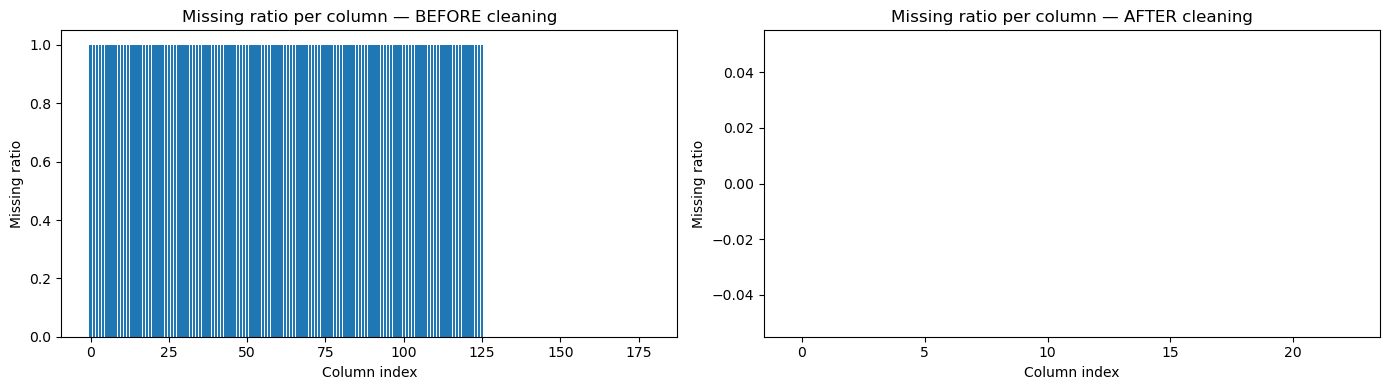

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
miss_before = train_raw.isna().mean().sort_values(ascending=False)
miss_after  = train_clean.isna().mean().sort_values(ascending=False)
axes[0].bar(range(len(miss_before)), miss_before.values)
axes[0].set_title("Missing ratio per column — BEFORE cleaning")
axes[0].set_xlabel("Column index"); axes[0].set_ylabel("Missing ratio")
axes[1].bar(range(len(miss_after)), miss_after.values, color="steelblue")
axes[1].set_title("Missing ratio per column — AFTER cleaning")
axes[1].set_xlabel("Column index"); axes[1].set_ylabel("Missing ratio")
plt.tight_layout(); plt.show()

---
## 2. Temporal Aggregation

Rolling window aggregation (mean) over `WINDOW_SIZE` days per disk.  
Also computes RUL and 3-class labels:
- **0** — RUL ≥ 20 days (healthy)
- **1** — 10 ≤ RUL < 20 days (warning)
- **2** — RUL < 10 days (critical)

In [146]:
print(f"Building training feature dataset (window={WINDOW_SIZE})...")
train_agg = build_feature_dataset(
    train_clean,
    window_size=WINDOW_SIZE,
    censored_rul_value=9999,
    drop_censored=False,
    patch_missing=False,
)
print(f"Train agg shape: {train_agg.shape}")
print("Label distribution:")
print(train_agg["label"].value_counts().sort_index())

Building training feature dataset (window=30)...
Generated 20 rolling features from 20 base numeric columns using window_size=30
Train agg shape: (626293, 26)
Label distribution:
label
0    617532
1      4220
2      4541
Name: count, dtype: int64


In [147]:
print(f"Building validation feature dataset (window={WINDOW_SIZE})...")
val_ids_df    = pd.read_csv(VAL_IDS)
val_labels_df = pd.read_csv(VAL_LABELS)

val_agg_features = temporal_aggregation(
    val_clean,
    window_size=WINDOW_SIZE,
)
val_agg = generate_validation_labels(
    val_agg_features, val_ids_df, val_labels_df,
    labeling_mode="all_windows",
)
print(f"Val agg shape: {val_agg.shape}")
print("Val label distribution:")
print(val_agg["label"].value_counts().sort_index())

Building validation feature dataset (window=30)...
Generated 20 rolling features from 20 base numeric columns using window_size=30
Val agg shape: (190, 24)
Val label distribution:
label
0    130
1     30
2     30
Name: count, dtype: int64


---
## 3. RFOD Anomaly Scores

RFOD (Random Forest Outlier Detection) trains one random forest per feature to predict
that feature from all others. Anomaly score = weighted Gower distance between
prediction and true value across all features.

Multiple thresholds `k` are used: for each `k`, RFOD is retrained treating
labels `0..k` as normal and `> k` as anomaly, producing `anomaly_score_k` columns.

### 3.1 RFOD Helper Functions

In [148]:
# Alpha values for Gower distance IQR normalisation
RFOD_ALPHA = [0, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.25]


def smape(y_true, y_pred):
    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-5))


def alphaquantile(matrix1, matrix2, categorical_columns, continuous_columns,
                  column_names, model_scores, residual, weighted=True):
    """Compute improved Gower distance for multiple alpha thresholds."""
    n_rows, n_cols = matrix1.shape
    result = {}
    for a in RFOD_ALPHA:
        diff_matrix = np.zeros((n_rows, n_cols))
        for col in continuous_columns:
            col_name = column_names[col]
            iqr = np.percentile(residual[col_name], 100 * (1 - a)) * 2
            if iqr == 0:
                scaled_diff = np.zeros_like(matrix1[:, col])
            else:
                scaled_diff = np.clip(np.abs(matrix1[:, col] - matrix2[:, col]) / iqr, 0, 1)
            diff_matrix[:, col] = scaled_diff
        for col_idx in categorical_columns:
            diff_matrix[:, col_idx] = 1 - matrix1[:, col_idx]  # false proba
        if weighted:
            mean_diff = np.sum(diff_matrix * np.array(model_scores), axis=1)
        else:
            mean_diff = np.mean(diff_matrix, axis=1)
        result[a] = (diff_matrix, mean_diff)
    return result


def calc_resi(col_name, Xy, treeid, model):
    X_resi = Xy.drop(columns=[col_name])
    y_resi = Xy[col_name]
    preds = sum(model.estimators_[idx].predict(X_resi.values) for idx in treeid)
    return np.abs(preds / len(treeid) - y_resi.values)


print("RFOD helper functions defined.")

RFOD helper functions defined.


In [149]:
# These two functions reference the global `_rfod_col_name` set during the training loop
_rfod_col_name = None  # will be set in the training loop


def _tree_scoring(tree, X, y, col_name, num_cols):
    if col_name in num_cols:
        y_pred = tree.predict(X)
        return smape(y, y_pred), y_pred
    else:
        y_pred = tree.predict_proba(X)
        n_cls = y_pred.shape[1]
        if n_cls != len(np.unique(y)) or n_cls <= 1:
            score = 0
        elif n_cls == 2:
            score = roc_auc_score(y, y_pred[:, 1])
        else:
            score = roc_auc_score(y, y_pred, multi_class="ovr")
        return 1 - score, y_pred


def _trees_scoring(y_preds, y, col_name, num_cols):
    y_preds = np.mean(y_preds, axis=0)
    if col_name in num_cols:
        return smape(y, y_preds)
    else:
        n_cls = y_preds.shape[1]
        if n_cls != len(np.unique(y)) or n_cls <= 1:
            return 1.0
        elif n_cls == 2:
            return 1 - roc_auc_score(y, y_preds[:, 1])
        else:
            return 1 - roc_auc_score(y, y_preds, multi_class="ovr")


def train_rf_feature(col_name, num_cols, categ_cols,
                     X_processed_train, X_processed_valid,
                     X_train, X_valid, process_list):
    """Train one RF per feature and select best tree subset via golden-section search."""
    rf_X_train = X_processed_train.drop(columns=process_list[col_name])
    rf_X_valid = X_processed_valid.drop(columns=process_list[col_name])
    rf_y_train = X_train[col_name]
    rf_y_valid = X_valid[col_name]

    if col_name in num_cols:
        rf_model = RandomForestRegressor(n_estimators=400, n_jobs=-1)
    else:
        rf_model = RandomForestClassifier(n_estimators=400, n_jobs=-1)

    t0 = time.time()
    rf_model.fit(rf_X_train.values, rf_y_train)
    tr_time = time.time() - t0

    trees = rf_model.estimators_
    t0 = time.time()
    output_trees = Parallel(n_jobs=-1)(
        delayed(_tree_scoring)(tree, rf_X_valid.values, rf_y_valid.values, col_name, num_cols)
        for tree in trees
    )
    errors, preds = zip(*output_trees)
    tree_oob_errors = np.asarray(errors, float)
    y_preds = np.stack(preds, axis=0)
    tree_indices = np.argsort(tree_oob_errors)
    sorted_errors = tree_oob_errors[tree_indices]

    # Golden-section search for best tree count
    trees_oob_errors = {}
    lef, rig = 0, 399
    while lef + 3 <= rig:
        midl = int(rig - (rig - lef) * 0.61803398875)
        midr = int(lef + (rig - lef) * 0.61803398875)
        for mid in (midl, midr):
            if mid not in trees_oob_errors:
                trees_oob_errors[mid] = (
                    _trees_scoring(y_preds[tree_indices[:mid + 1]], rf_y_valid.values, col_name, num_cols)
                    + sorted_errors[0] * 0.3 / np.sqrt((mid + 1) / 10)
                )
        if trees_oob_errors[midl] < trees_oob_errors[midr]:
            rig = midr
        else:
            lef = midl

    Best_trees = 5
    trees_oob_errors.setdefault(
        Best_trees,
        _trees_scoring(y_preds[tree_indices[:Best_trees + 1]], rf_y_valid.values, col_name, num_cols)
        + sorted_errors[0] * 0.3 / np.sqrt((Best_trees + 1) / 10)
    )
    for i in range(lef, rig + 1):
        trees_oob_errors.setdefault(
            i,
            _trees_scoring(y_preds[tree_indices[:i + 1]], rf_y_valid.values, col_name, num_cols)
            + sorted_errors[0] * 0.3 / np.sqrt((i + 1) / 10)
        )
        if trees_oob_errors[i] < trees_oob_errors[Best_trees]:
            Best_trees = i

    pr_time = time.time() - t0
    return {
        "tree_indices": tree_indices,
        "rf_model": rf_model,
        "tr_time": tr_time,
        "pr_time": pr_time,
        "tree_used": max(Best_trees, 5),
        "feature_performance": float(np.mean(sorted_errors[:max(1, Best_trees - 1)])),
    }


def predict_feature(col_name, tree_used, true_value, tree_indices, rf_model, num_cols,
                    X_processed_test, process_list):
    """Predict one feature from all others; return confidence scores and predictions."""
    top_idx = tree_indices[:tree_used]
    trees   = rf_model.estimators_
    predict_X = X_processed_test.drop(columns=process_list[col_name]).to_numpy()

    if col_name in num_cols:
        top_preds = np.array([trees[i].predict(predict_X) for i in top_idx])
        final_pred = top_preds.mean(axis=0)
        confidence_scores = np.std(top_preds, axis=0, ddof=1)
    else:
        class_idx_map = {label: i for i, label in enumerate(rf_model.classes_)}
        map_func = np.vectorize(lambda x: class_idx_map.get(x, -1))
        true_cls = map_func(true_value)
        valid = true_cls != -1
        true_proba = np.zeros((predict_X.shape[0], len(top_idx)))
        for j, idx in enumerate(top_idx):
            tp = trees[idx].predict_proba(predict_X)
            tt = np.zeros(predict_X.shape[0])
            tt[valid] = tp[np.arange(predict_X.shape[0])[valid], true_cls[valid]]
            true_proba[:, j] = tt
        final_pred = true_proba.mean(axis=1)
        confidence_scores = np.std(true_proba, axis=1, ddof=1)

    return {"confidence_scores": confidence_scores, "final_pred": final_pred}


print("RFOD core functions defined.")

RFOD core functions defined.


### 3.2 Data Preparation for RFOD

In [150]:
_meta_cols = {"date", "serial_number", "failure", "failure_date", "rul_days", "label"}

# --- train: failed disks (rul_days <= 60) ---
_bb_failed = train_agg[train_agg["rul_days"] <= 60].reset_index(drop=True)
_feat_cols = [c for c in _bb_failed.columns if c not in _meta_cols]

# --- train: sample normal rows from never-failed disks (rul_days == 9999) ---
CENSORED_SAMPLE_FRAC = 0.05   # adjust as needed
_bb_censored = (
    train_agg[train_agg["rul_days"] == 9999]
    .sample(frac=CENSORED_SAMPLE_FRAC, random_state=42)
    .reset_index(drop=True)
)
# label these as 0 (normal)
_bb_censored = _bb_censored.copy()
_bb_censored["label"] = 0

_bb_train = pd.concat([_bb_failed, _bb_censored], ignore_index=True)
X_bb_train = _bb_train[_feat_cols].reset_index(drop=True)
y_bb_train = _bb_train["label"].reset_index(drop=True)

print(f"Failed disk rows  : {len(_bb_failed)}")
print(f"Censored disk rows: {len(_bb_censored)}  (frac={CENSORED_SAMPLE_FRAC})")
print(f"Total train rows  : {len(_bb_train)}")
print(f"Label dist in train: {y_bb_train.value_counts().sort_index().to_dict()}")

# --- val: last window per disk (label already attached in Section 2) ---
_bb_val = val_agg.copy()
_bb_val["date"] = pd.to_datetime(_bb_val["date"], errors="coerce")
_bb_val_last = (
    _bb_val.sort_values(["serial_number", "date"])
           .drop_duplicates("serial_number", keep="last")
)
_val_feat_cols = [c for c in _feat_cols if c in _bb_val_last.columns]
X_bb_val = _bb_val_last[_val_feat_cols].reset_index(drop=True)
y_bb_val = _bb_val_last["label"].astype(int).reset_index(drop=True)

# Combined X / y_raw for RFOD (train + val)
X_all = pd.concat([X_bb_train[_val_feat_cols], X_bb_val], ignore_index=True)
y_raw = pd.concat([y_bb_train, y_bb_val], ignore_index=True)

# Drop all-NaN columns
always_nan = [c for c in X_all.columns if X_all[c].isna().all()]
X_all = X_all.drop(columns=always_nan)

y_binary = (y_raw > 0).astype(int)  # binary anomaly label for RFOD training

categ_cols = [c for c in ["model"] if c in X_all.columns]
num_cols   = [c for c in X_all.columns if c not in categ_cols]
fitonly    = []

print(f"X_all shape : {X_all.shape}")
print(f"y_raw dist  : {y_raw.value_counts().sort_index().to_dict()}")
print(f"y_binary    : anomaly={y_binary.sum()}, normal={( y_binary==0).sum()}")
print(f"Categorical : {categ_cols}")
print(f"Numerical   : {len(num_cols)} columns")

Failed disk rows  : 26063
Censored disk rows: 20949  (frac=0.05)
Total train rows  : 47012
Label dist in train: {0: 38251, 1: 4220, 2: 4541}
X_all shape : (47202, 20)
y_raw dist  : {0: 38381, 1: 4250, 2: 4571}
y_binary    : anomaly=8821, normal=38381
Categorical : []
Numerical   : 20 columns


### 3.3 Preprocessing (LabelEncoder + OHE + StandardScaler)

In [151]:
from imblearn.over_sampling import SMOTE

X_all = X_all.replace("?", np.nan)

# LabelEncode categoricals, median-fill numericals
_label_encoders = {}
_num_medians    = {}
for col in X_all.columns:
    if col in categ_cols:
        X_all[col] = X_all[col].fillna(X_all[col].mode()[0])
        le = LabelEncoder()
        X_all[col] = le.fit_transform(X_all[col])
        _label_encoders[col] = le
    else:
        _num_medians[col] = X_all[col].median()
        X_all[col] = X_all[col].fillna(_num_medians[col])

# Per-class SMOTE: oversample label=1 and label=2 separately,
# so synthetic samples keep correct y_raw labels for multi-threshold retraining.
print(f"Before SMOTE: label dist = {y_raw.value_counts().sort_index().to_dict()}")

synth_X_parts  = []
synth_yr_parts = []

for lbl in sorted(y_raw.unique()):
    if lbl == 0:
        continue  # normal class, no oversampling needed
    idx_normal = y_raw[y_raw == 0].index
    idx_lbl    = y_raw[y_raw == lbl].index
    n_normal   = len(idx_normal)
    n_lbl      = len(idx_lbl)
    if n_lbl >= n_normal or n_lbl < 2:
        continue  # already balanced or too few samples to interpolate
    X_sub = pd.concat([X_all.loc[idx_normal], X_all.loc[idx_lbl]], ignore_index=True)
    y_sub = pd.Series([0] * n_normal + [1] * n_lbl)
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_sub, y_sub)
    # only keep the newly generated minority samples
    n_new = int(y_res.sum()) - n_lbl
    if n_new > 0:
        X_new = pd.DataFrame(X_res[n_normal + n_lbl:], columns=X_all.columns)
        synth_X_parts.append(X_new)
        synth_yr_parts.append(pd.Series([lbl] * len(X_new)))
        print(f"  label={lbl}: {n_lbl} → +{len(X_new)} synthetic samples")

if synth_X_parts:
    X_all    = pd.concat([X_all]    + synth_X_parts,  ignore_index=True)
    y_raw    = pd.concat([y_raw]    + synth_yr_parts,  ignore_index=True)
    y_binary = (y_raw > 0).astype(int)

print(f"After  SMOTE: label dist = {y_raw.value_counts().sort_index().to_dict()}")
print(f"              normal={( y_binary==0).sum()}, anomaly={(y_binary==1).sum()}")

# Train / valid / test split (stratified: normal rows only for train/valid)
X_train_rfod = X_all[y_binary == 0].sample(frac=0.6, random_state=42)
X_valid_rfod = X_train_rfod.sample(frac=0.1 / 0.6, random_state=42)
X_test_rfod  = pd.concat([X_all[y_binary == 0].drop(X_train_rfod.index),
                           X_all[y_binary == 1]])
y_test_rfod  = y_binary.loc[X_test_rfod.index]

# Apply sample_frac
X_train_rfod = X_train_rfod.sample(frac=SAMPLE_FRAC, random_state=42)
X_valid_rfod = X_valid_rfod.sample(frac=SAMPLE_FRAC, random_state=42)

for df in (X_train_rfod, X_valid_rfod, X_test_rfod):
    df.reset_index(drop=True, inplace=True)
y_test_rfod = y_test_rfod.reset_index(drop=True)

test_ids = X_test_rfod.index.to_numpy()

print(f"X_train_rfod: {X_train_rfod.shape}")
print(f"X_valid_rfod: {X_valid_rfod.shape}")
print(f"X_test_rfod : {X_test_rfod.shape}  anomaly rate: {y_test_rfod.mean():.3%}")

Before SMOTE: label dist = {0: 38381, 1: 4250, 2: 4571}
  label=1: 4250 → +34131 synthetic samples
  label=2: 4571 → +33810 synthetic samples
After  SMOTE: label dist = {0: 38381, 1: 38381, 2: 38381}
              normal=38381, anomaly=76762
X_train_rfod: (11514, 20)
X_valid_rfod: (1919, 20)
X_test_rfod : (92114, 20)  anomaly rate: 83.334%


In [152]:
# OHE for categoricals, StandardScaler for numericals
process_list     = {}
_onehot_encoders = {}
Xp_train = pd.DataFrame()
Xp_valid = pd.DataFrame()
Xp_test  = pd.DataFrame()

for col in categ_cols:
    enc = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
    ohe_tr = enc.fit_transform(X_train_rfod[[col]])
    _onehot_encoders[col] = enc
    process_list[col] = [f"{col}_{cat}" for cat in enc.categories_[0][1:]]
    Xp_train = pd.concat([Xp_train, pd.DataFrame(ohe_tr,                           columns=process_list[col])], axis=1)
    Xp_valid = pd.concat([Xp_valid, pd.DataFrame(enc.transform(X_valid_rfod[[col]]), columns=process_list[col])], axis=1)
    Xp_test  = pd.concat([Xp_test,  pd.DataFrame(enc.transform(X_test_rfod[[col]]),  columns=process_list[col])], axis=1)

for col in num_cols:
    process_list[col] = [col]

scaler = StandardScaler()
Xp_train = pd.concat([Xp_train, pd.DataFrame(scaler.fit_transform(X_train_rfod[num_cols]), columns=num_cols)], axis=1)
Xp_valid = pd.concat([Xp_valid, pd.DataFrame(scaler.transform(X_valid_rfod[num_cols]),     columns=num_cols)], axis=1)
Xp_test  = pd.concat([Xp_test,  pd.DataFrame(scaler.transform(X_test_rfod[num_cols]),      columns=num_cols)], axis=1)

for df in (Xp_train, Xp_valid, Xp_test):
    df.reset_index(drop=True, inplace=True)

print(f"Xp_train: {Xp_train.shape}")
print(f"Xp_test : {Xp_test.shape}")

Xp_train: (11514, 20)
Xp_test : (92114, 20)


### 3.4 Train Per-Feature Random Forests

In [153]:
Tid          = {}
rFM          = {}
Feature_tree_used = {}

t_start = time.time()
for col in X_train_rfod.columns:
    if col in fitonly:
        continue
    print(f"  Training RF for: {col}")
    res = train_rf_feature(
        col, num_cols, categ_cols,
        Xp_train, Xp_valid,
        X_train_rfod, X_valid_rfod,
        process_list,
    )
    Tid[col]               = res["tree_indices"]
    rFM[col]               = res["rf_model"]
    Feature_tree_used[col] = res["tree_used"]

print(f"\nTotal training time: {time.time() - t_start:.1f}s")

  Training RF for: capacity_bytes_mean
  Training RF for: smart_1_raw_mean
  Training RF for: smart_3_normalized_mean
  Training RF for: smart_4_raw_mean
  Training RF for: smart_5_raw_mean
  Training RF for: smart_7_raw_mean
  Training RF for: smart_9_raw_mean
  Training RF for: smart_12_raw_mean
  Training RF for: smart_183_raw_mean
  Training RF for: smart_184_raw_mean
  Training RF for: smart_187_raw_mean
  Training RF for: smart_188_raw_mean
  Training RF for: smart_190_raw_mean
  Training RF for: smart_192_raw_mean
  Training RF for: smart_193_raw_mean
  Training RF for: smart_197_raw_mean
  Training RF for: smart_199_raw_mean
  Training RF for: smart_240_raw_mean
  Training RF for: smart_241_raw_mean
  Training RF for: smart_242_raw_mean

Total training time: 50.6s


### 3.5 Compute Residuals and Score Test Set

In [154]:
# Residuals on validation set (used for IQR normalisation in alphaquantile)
residual = {}
for col in num_cols:
    residual[col] = np.sort(calc_resi(
        col, Xp_valid,
        Tid[col][:Feature_tree_used[col]], rFM[col],
    ))

# Predict each feature on test set
Conf_Pre = {}
for col in X_train_rfod.columns:
    if col in fitonly:
        continue
    Conf_Pre[col] = predict_feature(
        col, Feature_tree_used[col],
        X_test_rfod[col].values,
        Tid[col], rFM[col], num_cols,
        Xp_test, process_list,
    )

predcol = [c for c in X_train_rfod.columns if c not in fitonly]
conf_combined = pd.DataFrame({c: Conf_Pre[c]["confidence_scores"] for c in predcol})[predcol]
all_y_pred_rf = pd.DataFrame({c: Conf_Pre[c]["final_pred"]        for c in predcol})[predcol]

# Feature weights (normalised inverse confidence)
fw = conf_combined.to_numpy().copy()
for i in range(fw.shape[0]):
    s = fw[i].sum()
    if s: fw[i] /= s
fw = 1 - fw
for i in range(fw.shape[0]):
    s = fw[i].sum()
    if s: fw[i] /= s
fw = np.square(fw)
fw = fw / np.sum(fw, axis=1, keepdims=True)

X_test_pred = X_test_rfod.drop(columns=fitonly)
categ_idx = [i for i, c in enumerate(X_test_pred.columns) if c in categ_cols]
num_idx   = [i for i, c in enumerate(X_test_pred.columns) if c in num_cols]

result = alphaquantile(
    all_y_pred_rf.values, X_test_pred.values,
    categ_idx, num_idx, X_test_pred.columns,
    fw, residual, weighted=True,
)

print("Alphaquantile scoring done.")

Alphaquantile scoring done.


### 3.6 Alpha Sweep → Best AUCROC Alpha

In [155]:
best_aucroc       = -1
best_aucroc_alpha = None
best_avpr         = -1
best_avpr_alpha   = None
alpha_metrics     = []

thresholds = np.arange(0.001, 1.001, 0.001)

for a, (_, scores_a) in result.items():
    aucroc = roc_auc_score(y_test_rfod, scores_a)
    avpr   = average_precision_score(y_test_rfod, scores_a)

    best_f1_a = max(
        f1_score(y_test_rfod, (scores_a > t).astype(int), zero_division=0)
        for t in thresholds
    )
    alpha_metrics.append({"alpha": a, "aucroc": aucroc, "avpr": avpr, "best_f1": best_f1_a})

    if aucroc > best_aucroc:
        best_aucroc       = aucroc
        best_aucroc_alpha = a
    if avpr > best_avpr:
        best_avpr         = avpr
        best_avpr_alpha   = a

alpha_df = pd.DataFrame(alpha_metrics).set_index("alpha")
print(f"Best AUCROC: {best_aucroc:.4f}  (alpha={best_aucroc_alpha})")
print(f"Best AVPR  : {best_avpr:.4f}  (alpha={best_avpr_alpha})")
print()
print(alpha_df.round(4).to_string())

Best AUCROC: 0.8018  (alpha=0.25)
Best AVPR  : 0.9540  (alpha=0.2)

       aucroc    avpr  best_f1
alpha                         
0.000  0.7413  0.9269   0.9102
0.001  0.7570  0.9333   0.9131
0.002  0.7655  0.9375   0.9151
0.005  0.7612  0.9371   0.9186
0.010  0.7594  0.9370   0.9187
0.020  0.7628  0.9385   0.9182
0.050  0.7818  0.9460   0.9168
0.100  0.7924  0.9512   0.9158
0.200  0.8010  0.9540   0.9151
0.250  0.8018  0.9540   0.9150


### 3.7 Multi-Threshold Retraining and Scoring

For each label threshold `k ∈ {1, 2}`, retrain RFOD treating labels `0..k` as normal.
Then score the full train and val CSVs with `anomaly_score_0`, `anomaly_score_1`, `anomaly_score_2`.

In [156]:
def _safe_le_transform(le, values):
    arr = np.asarray(values)
    known = np.array([v in set(le.classes_) for v in arr])
    result = np.full(len(arr), -1, dtype=np.int64)
    if known.any():
        result[known] = le.transform(arr[known])
    return result


_agg_feat_cols = list(X_all.columns)


def _preprocess_for_scoring(df_orig, sc=None, ohe_k=None, plist_k=None):
    """Preprocess a DataFrame using base (or threshold-k) encoders."""
    _ohe   = ohe_k   if ohe_k   is not None else _onehot_encoders
    _plist = plist_k if plist_k is not None else process_list
    _sc    = sc      if sc      is not None else scaler

    df = df_orig[[c for c in _agg_feat_cols if c in df_orig.columns]].copy().replace("?", np.nan)
    available_cols = df.columns.tolist()

    for col in available_cols:
        if col in categ_cols:
            fill = df[col].mode()
            df[col] = df[col].fillna(fill[0] if len(fill) > 0 else 0)
            df[col] = _safe_le_transform(_label_encoders[col], df[col].values)
        else:
            df[col] = df[col].fillna(_num_medians.get(col, 0))
    df.reset_index(drop=True, inplace=True)

    X_proc = pd.DataFrame()
    for col in categ_cols:
        if col not in _ohe:
            continue
        ohe_vals = _ohe[col].transform(df[[col]])
        X_proc = pd.concat([X_proc, pd.DataFrame(ohe_vals, columns=_plist[col])], axis=1)
    nc = [c for c in num_cols if c in available_cols]
    X_proc = pd.concat([X_proc, pd.DataFrame(_sc.transform(df[nc]), columns=nc)], axis=1)
    X_proc.reset_index(drop=True, inplace=True)
    return df, X_proc


def _score_rows(X_raw, X_proc, alpha_val, Ftree, rfm, Tid_, resid, pl):
    """Compute RFOD anomaly scores for a batch of rows."""
    Conf = {}
    for col in X_raw.columns:
        if col in fitonly or col not in Ftree:
            continue
        Conf[col] = predict_feature(
            col, Ftree[col], X_raw[col].values,
            Tid_[col], rfm[col], num_cols, X_proc, pl,
        )

    pcols = [c for c in X_raw.columns if c not in fitonly and c in Ftree]
    conf_ = pd.DataFrame({c: Conf[c]["confidence_scores"] for c in pcols})[pcols]
    pred_ = pd.DataFrame({c: Conf[c]["final_pred"]        for c in pcols})[pcols]

    fw_ = conf_.to_numpy().copy()
    for i in range(fw_.shape[0]):
        s = fw_[i].sum()
        if s: fw_[i] /= s
    fw_ = 1 - fw_
    for i in range(fw_.shape[0]):
        s = fw_[i].sum()
        if s: fw_[i] /= s
    fw_ = np.square(fw_)
    fw_ = fw_ / np.sum(fw_, axis=1, keepdims=True)

    ci = [i for i, c in enumerate(X_raw.columns) if c in categ_cols]
    ni = [i for i, c in enumerate(X_raw.columns) if c in num_cols]
    res_ = alphaquantile(pred_.values, X_raw.values, ci, ni, X_raw.columns, fw_, resid, weighted=True)
    _, scores = res_[alpha_val]
    return scores


def _find_best_alpha(X_te, Xp_te, y_te, Ftree, rfm, Tid_, resid, pl):
    """Alpha sweep on a test set; return alpha with best AUCROC."""
    Conf = {}
    for col in X_te.columns:
        if col in fitonly or col not in Ftree:
            continue
        Conf[col] = predict_feature(
            col, Ftree[col], X_te[col].values,
            Tid_[col], rfm[col], num_cols, Xp_te, pl,
        )

    pcols = [c for c in X_te.columns if c not in fitonly and c in Ftree]
    conf_ = pd.DataFrame({c: Conf[c]["confidence_scores"] for c in pcols})[pcols]
    pred_ = pd.DataFrame({c: Conf[c]["final_pred"]        for c in pcols})[pcols]

    fw_ = conf_.to_numpy().copy()
    for i in range(fw_.shape[0]):
        s = fw_[i].sum()
        if s: fw_[i] /= s
    fw_ = 1 - fw_
    for i in range(fw_.shape[0]):
        s = fw_[i].sum()
        if s: fw_[i] /= s
    fw_ = np.square(fw_)
    fw_ = fw_ / np.sum(fw_, axis=1, keepdims=True)

    ci = [i for i, c in enumerate(X_te.columns) if c in categ_cols]
    ni = [i for i, c in enumerate(X_te.columns) if c in num_cols]
    result = alphaquantile(pred_.values, X_te.values, ci, ni, X_te.columns, fw_, resid, weighted=True)

    best_alpha, best_aucroc = None, -1
    for a, (_, scores_a) in result.items():
        if y_te.nunique() < 2:
            continue
        auc = roc_auc_score(y_te, scores_a)
        if auc > best_aucroc:
            best_aucroc = auc
            best_alpha  = a
    return best_alpha, best_aucroc


def _retrain_for_threshold(k):
    """Retrain RFOD treating y_raw <= k as normal; find best alpha for this k."""
    y_k = (y_raw.values > k).astype(int)
    mask_normal = y_k == 0

    _Xtr = X_all[mask_normal].sample(frac=0.6, random_state=42)
    _Xvl = _Xtr.sample(frac=0.1 / 0.6, random_state=42)
    _Xte_normal  = X_all[mask_normal].drop(_Xtr.index)
    _Xte_anomaly = X_all[~mask_normal]
    _Xte = pd.concat([_Xte_normal, _Xte_anomaly])
    _yte = pd.Series(
        [0] * len(_Xte_normal) + [1] * len(_Xte_anomaly),
        name="y",
    ).reset_index(drop=True)

    _Xtr = _Xtr.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    _Xvl = _Xvl.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    _Xte = _Xte.reset_index(drop=True)

    _plist_k, _ohe_k = {}, {}
    _Xp_tr = pd.DataFrame(); _Xp_vl = pd.DataFrame(); _Xp_te = pd.DataFrame()
    for c in categ_cols:
        enc = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
        tr_ohe = enc.fit_transform(_Xtr[[c]])
        _ohe_k[c]   = enc
        _plist_k[c] = [f"{c}_{cat}" for cat in enc.categories_[0][1:]]
        _Xp_tr = pd.concat([_Xp_tr, pd.DataFrame(tr_ohe,                    columns=_plist_k[c])], axis=1)
        _Xp_vl = pd.concat([_Xp_vl, pd.DataFrame(enc.transform(_Xvl[[c]]), columns=_plist_k[c])], axis=1)
        _Xp_te = pd.concat([_Xp_te, pd.DataFrame(enc.transform(_Xte[[c]]), columns=_plist_k[c])], axis=1)

    for c in num_cols:
        _plist_k[c] = [c]

    _sc_k = StandardScaler()
    nc_k  = [c for c in num_cols if c in _Xtr.columns]
    _Xp_tr = pd.concat([_Xp_tr, pd.DataFrame(_sc_k.fit_transform(_Xtr[nc_k]), columns=nc_k)], axis=1)
    _Xp_vl = pd.concat([_Xp_vl, pd.DataFrame(_sc_k.transform(_Xvl[nc_k]),    columns=nc_k)], axis=1)
    _Xp_te = pd.concat([_Xp_te, pd.DataFrame(_sc_k.transform(_Xte[nc_k]),    columns=nc_k)], axis=1)
    for df in (_Xp_tr, _Xp_vl, _Xp_te):
        df.reset_index(drop=True, inplace=True)

    _Ftree_k, _rFM_k, _Tid_k = {}, {}, {}
    for col in _Xtr.columns:
        if col in fitonly:
            continue
        r = train_rf_feature(col, num_cols, categ_cols, _Xp_tr, _Xp_vl, _Xtr, _Xvl, _plist_k)
        _Tid_k[col]   = r["tree_indices"]
        _rFM_k[col]   = r["rf_model"]
        _Ftree_k[col] = r["tree_used"]

    _resid_k = {
        col: np.sort(calc_resi(col, _Xp_vl, _Tid_k[col][:_Ftree_k[col]], _rFM_k[col]))
        for col in num_cols if col not in fitonly
    }

    # Find best alpha for this threshold k
    _best_alpha_k, _best_aucroc_k = _find_best_alpha(
        _Xte, _Xp_te, _yte, _Ftree_k, _rFM_k, _Tid_k, _resid_k, _plist_k
    )
    print(f"  k={k}: best_alpha={_best_alpha_k}  AUCROC={_best_aucroc_k:.4f}")

    return _Ftree_k, _rFM_k, _Tid_k, _resid_k, _sc_k, _ohe_k, _plist_k, _best_alpha_k


print("Scoring helpers defined.")

Scoring helpers defined.


In [157]:
# Determine label thresholds (exclude max label — no anomalies left)
_all_labels     = sorted(int(v) for v in y_raw.unique() if pd.notna(v))
_score_thresholds = _all_labels[:-1]
print(f"Label values: {_all_labels}  →  score thresholds: {_score_thresholds}")

extra_models = {}
for k in _score_thresholds:
    if k == 0:
        continue
    print(f"\nRetraining RFOD for threshold k={k} (normal = labels 0..{k})...")
    extra_models[k] = _retrain_for_threshold(k)  # returns (..., best_alpha_k)
    print(f"Done k={k}")

Label values: [0, 1, 2]  →  score thresholds: [0, 1]

Retraining RFOD for threshold k=1 (normal = labels 0..1)...


  k=1: best_alpha=0.1  AUCROC=0.8292
Done k=1


### 3.8 Score Train CSV (Chunked) and Validation Set

In [158]:
print("Scoring train set (chunked from memory)...")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

chunk_size = 5000
first = True
total = 0
for start in range(0, len(train_agg), chunk_size):
    chunk = train_agg.iloc[start:start + chunk_size].copy()
    xr0, xp0 = _preprocess_for_scoring(chunk)
    chunk["anomaly_score_0"] = _score_rows(xr0, xp0, best_aucroc_alpha,
                                            Feature_tree_used, rFM, Tid, residual, process_list)
    for k, arts in extra_models.items():
        Ft_k, rfm_k, Tid_k, resid_k, sc_k, ohe_k, plist_k, alpha_k = arts
        xrk, xpk = _preprocess_for_scoring(chunk, sc=sc_k, ohe_k=ohe_k, plist_k=plist_k)
        chunk[f"anomaly_score_{k}"] = _score_rows(xrk, xpk, alpha_k,
                                                   Ft_k, rfm_k, Tid_k, resid_k, plist_k)
    chunk.to_csv(TRAIN_AGG_OUT, mode="w" if first else "a", header=first, index=False)
    first = False
    total += len(chunk)
    print(f"  train processed {total} rows")

print(f"Train saved: {total} rows → {TRAIN_AGG_OUT}")

Scoring train set (chunked from memory)...
  train processed 5000 rows
  train processed 10000 rows
  train processed 15000 rows
  train processed 20000 rows
  train processed 25000 rows
  train processed 30000 rows
  train processed 35000 rows
  train processed 40000 rows
  train processed 45000 rows
  train processed 50000 rows
  train processed 55000 rows
  train processed 60000 rows
  train processed 65000 rows
  train processed 70000 rows
  train processed 75000 rows
  train processed 80000 rows
  train processed 85000 rows
  train processed 90000 rows


  train processed 95000 rows
  train processed 100000 rows
  train processed 105000 rows
  train processed 110000 rows
  train processed 115000 rows
  train processed 120000 rows
  train processed 125000 rows
  train processed 130000 rows
  train processed 135000 rows
  train processed 140000 rows
  train processed 145000 rows
  train processed 150000 rows
  train processed 155000 rows
  train processed 160000 rows
  train processed 165000 rows
  train processed 170000 rows
  train processed 175000 rows
  train processed 180000 rows
  train processed 185000 rows
  train processed 190000 rows
  train processed 195000 rows
  train processed 200000 rows
  train processed 205000 rows
  train processed 210000 rows
  train processed 215000 rows
  train processed 220000 rows
  train processed 225000 rows
  train processed 230000 rows
  train processed 235000 rows
  train processed 240000 rows
  train processed 245000 rows
  train processed 250000 rows
  train processed 255000 rows
  train pro

In [159]:
print("Scoring validation set...")

# Reconstruct validation rows and retain the disk-level label for export
_bb_val_full = val_agg.copy()
_bb_val_full["date"] = pd.to_datetime(_bb_val_full["date"], errors="coerce")
_lbl_map = (
    _bb_val_full.sort_values(["serial_number", "date"])
    .drop_duplicates("serial_number", keep="last")[["serial_number", "label"]]
    .rename(columns={"label": "_lbl"})
)
_bb_val_full = _bb_val_full.drop(columns=["label"], errors="ignore")
_bb_val_full = _bb_val_full.merge(_lbl_map, on="serial_number", how="left")
_bb_val_full["label"] = _bb_val_full["_lbl"].fillna(-1).astype(int)
_bb_val_full.drop(columns=["_lbl"], inplace=True)
_bb_val_full.reset_index(drop=True, inplace=True)

out_val = _bb_val_full.drop(columns=["label"], errors="ignore").copy()

vr0, vp0 = _preprocess_for_scoring(_bb_val_full)
out_val["anomaly_score_0"] = _score_rows(vr0, vp0, best_aucroc_alpha,
                                          Feature_tree_used, rFM, Tid, residual, process_list)
for k, arts in extra_models.items():
    Ft_k, rfm_k, Tid_k, resid_k, sc_k, ohe_k, plist_k, alpha_k = arts
    vrk, vpk = _preprocess_for_scoring(_bb_val_full, sc=sc_k, ohe_k=ohe_k, plist_k=plist_k)
    out_val[f"anomaly_score_{k}"] = _score_rows(vrk, vpk, alpha_k,
                                                 Ft_k, rfm_k, Tid_k, resid_k, plist_k)

out_val["label"] = _bb_val_full["label"].to_numpy()

out_val.to_csv(VAL_AGG_OUT, index=False)
print(f"Val saved: {len(out_val)} rows → {VAL_AGG_OUT}")

Scoring validation set...
Val saved: 190 rows → /home/ruiyao/cs_5344/Project/Datasets/Backblaze/clean/backblaze_clean_val_feature_agg.csv


In [160]:
# Reload and inspect scored files
train_scored = pd.read_csv(TRAIN_AGG_OUT, parse_dates=["date"], low_memory=False)
val_scored   = pd.read_csv(VAL_AGG_OUT,   parse_dates=["date"], low_memory=False)

score_cols = [c for c in train_scored.columns if c.startswith("anomaly_score")]
print(f"Anomaly score columns: {score_cols}")
print(f"Train scored shape: {train_scored.shape}")
print(f"Val scored shape  : {val_scored.shape}")
train_scored[score_cols].describe().round(4)

Anomaly score columns: ['anomaly_score_0', 'anomaly_score_1']
Train scored shape: (626293, 28)
Val scored shape  : (190, 25)


,anomaly_score_0,anomaly_score_1
count,626293.0000,626293.0000
mean,0.0512,0.0306
std,0.0581,0.0359
min,0.0000,0.0000
25%,0.0115,0.0080
50%,0.0286,0.0172
75%,0.0675,0.0380
max,0.4267,0.4462


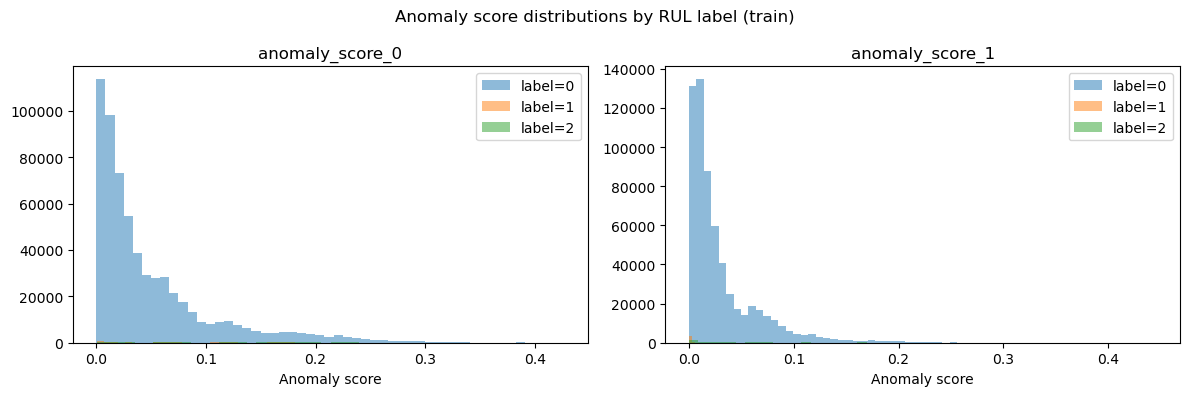

Spearman correlation (anomaly score vs label):
  anomaly_score_0: 0.0854
  anomaly_score_1: -0.0558


In [161]:
if score_cols and "label" in train_scored.columns:
    n = len(score_cols)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), squeeze=False)
    for ax, sc in zip(axes[0], score_cols):
        for lbl, grp in train_scored.groupby("label"):
            ax.hist(grp[sc].dropna(), bins=50, alpha=0.5, label=f"label={lbl}")
        ax.set_title(sc); ax.set_xlabel("Anomaly score"); ax.legend()
    plt.suptitle("Anomaly score distributions by RUL label (train)")
    plt.tight_layout(); plt.show()

print("Spearman correlation (anomaly score vs label):")
for sc in score_cols:
    corr = train_scored[[sc, "label"]].dropna().corr(method="spearman").loc[sc, "label"]
    print(f"  {sc}: {corr:.4f}")

---
## 4. XGBoost Classification

Train an XGBoost multi-class classifier (3 classes: label 0/1/2) using
the temporally aggregated features + RFOD anomaly scores.
Hyperparameters are tuned via `RandomizedSearchCV` with `StratifiedGroupKFold`.

### 4.1 Training Setup

This section trains the final XGBoost classifier on the **temporally aggregated + RFOD-scored** dataset only. The training split uses **all failed disks** plus a sampled set of **non-failure disks (last window only)** so the model can still observe healthy patterns without overwhelming the failure-driven training rows. The validation split is kept **unchanged** and evaluated on the **last available readout per disk**, which matches the final project requirement of one prediction per disk.

In [ ]:
from train_xgboost_backblaze import search_optimal_thresholds

XGB_CV_SPLITS = 3
XGB_SEARCH_ITER = 10
THRESHOLD_STEPS = 20
NONFAILURE_SAMPLING_MODE = 'last_window'
NONFAILURE_SAMPLE_FRAC = 0.10
NONFAILURE_FEW_WINDOWS = 3

print('XGBoost configuration')
print({
    'cv_splits': XGB_CV_SPLITS,
    'search_iter': XGB_SEARCH_ITER,
    'threshold_steps': THRESHOLD_STEPS,
    'nonfailure_sampling_mode': NONFAILURE_SAMPLING_MODE,
    'nonfailure_sample_frac': NONFAILURE_SAMPLE_FRAC,
})

In [ ]:
X_train_xgb, y_train_xgb, train_groups_xgb, X_val_xgb, y_val_xgb = load_aggregated_train_val(
    TRAIN_AGG_OUT,
    VAL_AGG_OUT,
    train_failed_disks_only=True,
    nonfailure_sampling_mode=NONFAILURE_SAMPLING_MODE,
    nonfailure_sample_frac=NONFAILURE_SAMPLE_FRAC,
    nonfailure_few_windows_per_disk=NONFAILURE_FEW_WINDOWS,
)

print('Prepared aggregated dataset bundle for XGBoost')
print(f'  Train shape : {X_train_xgb.shape}')
print(f'  Val shape   : {X_val_xgb.shape}')
print(f'  Train disks : {train_groups_xgb.nunique()}')
print('  Train labels:')
print(y_train_xgb.value_counts().sort_index().to_string())
print('  Val labels  :')
print(y_val_xgb.value_counts().sort_index().to_string())

### 4.2 Hyperparameter Tuning and Model Fit

We reuse the grouped cross-validation strategy from the training script so that rows from the same disk never appear in both the training and validation folds during hyperparameter search.

In [ ]:
X_train_xgb_aligned, X_val_xgb_aligned = align_feature_frames(X_train_xgb.copy(), X_val_xgb.copy())

xgb_pipeline = build_model_pipeline(X_train_xgb_aligned)
xgb_search = tune_pipeline(
    pipeline=xgb_pipeline,
    X_train=X_train_xgb_aligned,
    y_train=y_train_xgb,
    groups=train_groups_xgb,
    n_splits=XGB_CV_SPLITS,
    n_iter=XGB_SEARCH_ITER,
)

xgb_model = xgb_search.best_estimator_

print('Best CV macro F1:', round(float(xgb_search.best_score_), 4))
print('Best parameters:')
print(json.dumps(xgb_search.best_params_, indent=2, default=float))

### 4.3 Validation Metrics and Threshold Moving

Two prediction rules are compared on the unchanged validation set:

- `argmax`: default XGBoost class prediction
- `threshold moving`: cost-sensitive post-processing using the ordered thresholds from the project script

The threshold search uses the same constrained configuration as the final training program.

In [ ]:
y_pred = xgb_model.predict(X_val_xgb_aligned)
y_pred_proba = xgb_model.predict_proba(X_val_xgb_aligned)

default_metrics = evaluate_predictions(y_val_xgb, y_pred, y_pred_proba)
threshold_result = search_optimal_thresholds(
    y_val_xgb,
    y_pred_proba,
    threshold_steps=THRESHOLD_STEPS,
    theta_1_min=0.2,
    theta_1_max=0.8,
    theta_2_min=0.1,
    theta_2_max=0.8,
    safe_recall_min=0.7,
    enforce_theta_order=True,
)
y_pred_threshold = threshold_result.y_pred
threshold_metrics = evaluate_predictions(y_val_xgb, y_pred_threshold, y_pred_proba)

comparison_df = pd.DataFrame([
    {
        'strategy': 'argmax',
        'accuracy': default_metrics['accuracy'],
        'balanced_accuracy': default_metrics['balanced_accuracy'],
        'macro_f1': default_metrics['macro_f1'],
        'weighted_f1': default_metrics['weighted_f1'],
        'aucroc_ovr_macro': default_metrics['aucroc_ovr_macro'],
        'aucroc_ovo_macro': default_metrics['aucroc_ovo_macro'],
        'total_cost': default_metrics['total_cost'],
    },
    {
        'strategy': 'threshold_moving',
        'accuracy': threshold_metrics['accuracy'],
        'balanced_accuracy': threshold_metrics['balanced_accuracy'],
        'macro_f1': threshold_metrics['macro_f1'],
        'weighted_f1': threshold_metrics['weighted_f1'],
        'aucroc_ovr_macro': threshold_metrics['aucroc_ovr_macro'],
        'aucroc_ovo_macro': threshold_metrics['aucroc_ovo_macro'],
        'total_cost': threshold_metrics['total_cost'],
    },
]).set_index('strategy')

print('Threshold moving result:')
print({
    'theta_1': round(float(threshold_result.theta_1), 4),
    'theta_2': round(float(threshold_result.theta_2), 4),
    'used_constraints': threshold_result.used_constraints,
})

display(comparison_df.round(4))

print('Validation classification report — argmax')
print(classification_report(y_val_xgb, y_pred, digits=4, zero_division=0))

print('Validation classification report — threshold moving')
print(classification_report(y_val_xgb, y_pred_threshold, digits=4, zero_division=0))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tick_labels = ['0 (safe)', '1 (warning)', '2 (critical)']

for ax, preds, title, total in [
    (axes[0], y_pred, 'Argmax', default_metrics['total_cost']),
    (axes[1], y_pred_threshold, 'Threshold moving', threshold_metrics['total_cost']),
]:
    cm = confusion_matrix(y_val_xgb, preds, labels=[0, 1, 2])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=tick_labels, yticklabels=tick_labels, ax=ax
    )
    ax.set_title(f'{title} (cost={total})')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.suptitle('XGBoost validation confusion matrices')
plt.tight_layout()
plt.show()

---
## 5. Cost Matrix RUL Prediction

Asymmetric cost matrix (rows = true label, cols = predicted label):
```
       Pred 0  Pred 1  Pred 2
True 0    0       1       3
True 1    4       0       2
True 2   15       5       0
```
Compare default `argmax` against expected-cost-minimising predictions.

In [163]:
# print("Cost matrix:")
# print(pd.DataFrame(COST_MATRIX,
#                    index=["True 0", "True 1", "True 2"],
#                    columns=["Pred 0", "Pred 1", "Pred 2"]).to_string())
# print(f"\nDefault argmax total cost: {total_cost(y_val_xgb, y_pred)}")

In [164]:
# def cost_minimising_predict(proba, cost_matrix):
#     """Pick class c* minimising expected cost: sum_j P(true=j) * cost[j, c]."""
#     return np.argmin(proba @ cost_matrix, axis=1)


# y_cost_pred = cost_minimising_predict(y_pred_proba, COST_MATRIX)
# print(f"Cost-minimising total cost: {total_cost(y_val_xgb, y_cost_pred)}")
# print(f"Improvement over argmax   : {total_cost(y_val_xgb, y_pred) - total_cost(y_val_xgb, y_cost_pred)}")

In [165]:
# rows = []
# for name, preds in [("argmax", y_pred), ("cost-minimising", y_cost_pred)]:
#     rows.append({
#         "strategy"         : name,
#         "accuracy"         : accuracy_score(y_val_xgb, preds),
#         "balanced_accuracy": balanced_accuracy_score(y_val_xgb, preds),
#         "macro_f1"         : f1_score(y_val_xgb, preds, average="macro", zero_division=0),
#         "total_cost"       : total_cost(y_val_xgb, preds),
#     })
# print(pd.DataFrame(rows).set_index("strategy").round(4).to_string())

In [166]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# tick_labels = ["0 (healthy)", "1 (warning)", "2 (critical)"]
# for ax, (name, preds) in zip(axes, [("argmax", y_pred), ("cost-minimising", y_cost_pred)]):
#     cm = confusion_matrix(y_val_xgb, preds, labels=[0, 1, 2])
#     sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#                 xticklabels=tick_labels, yticklabels=tick_labels, ax=ax)
#     ax.set_title(f"{name}  (cost={total_cost(y_val_xgb, preds)})")
#     ax.set_xlabel("Predicted"); ax.set_ylabel("True")
# plt.suptitle("Prediction strategy comparison — Validation Set")
# plt.tight_layout(); plt.show()

In [167]:
# y_val_arr  = np.asarray(y_val_xgb, dtype=int)
# y_pred_arr = np.asarray(y_pred, dtype=int)
# y_cost_arr = np.asarray(y_cost_pred, dtype=int)
# breakdown = pd.DataFrame({
#     "true_label"           : y_val_arr,
#     "cost_argmax"          : COST_MATRIX[y_val_arr, y_pred_arr],
#     "cost_cost_minimising" : COST_MATRIX[y_val_arr, y_cost_arr],
# })
# print("Mean cost per true label class:")
# print(breakdown.groupby("true_label")[["cost_argmax", "cost_cost_minimising"]].mean().round(3).to_string())